# 1. Análise Analítica de Seção Circular 2D (Modos TE e TM)

Este notebook calcula os parâmetros fundamentais de uma estrutura circular 2D para os modos transversos (TE e TM). A análise passa para o sistema de coordenadas polares ($r, \phi$), onde o raio máximo da estrutura é $R$.

A análise em 2D foca na frequência de corte ($f_c$) em vez da frequência de ressonância de uma cavidade fechada. 

## 1.1 Frequência de Corte e Números de Onda

Para estruturas circulares, as ondas no interior são descritas pelas Funções de Bessel do primeiro tipo, $J_n(x)$. Os índices do modo genérico $TE_{nm}$ e $TM_{nm}$ indicam:
* **$n$**: Índice azimutal (número de variações ao longo do ângulo $\phi$).
* **$m$**: Índice radial (número de raízes/nodos ao longo do raio $r$).

O número de onda de corte ($k_c$) depende das raízes das funções de Bessel:
* Para **TM**, usamos as raízes da função de Bessel pura ($p_{nm}$): $k_{c} = \frac{p_{nm}}{R}$
* Para **TE**, usamos as raízes da derivada da função de Bessel ($p'_{nm}$): $k_{c} = \frac{p'_{nm}}{R}$

A frequência de corte teórica é calculada por:
$f_{c_{nm}} = \frac{c}{2\pi\sqrt{\mu_r\epsilon_r}} k_{c_{nm}}$

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc
import scipy.special as sp

class SecaoCircular2D:
    def __init__(self, R, er=1.0):
        """
        Inicializa os parâmetros da seção transversal circular 2D.
        R: Raio em metros
        er: Permissividade relativa do dielétrico
        """
        self.R = R
        self.er = er
        self.c = sc.c / np.sqrt(er)
        
    def k_c(self, n, m, tipo_modo):
        """Calcula o número de onda de corte usando raízes de Bessel."""
        # A função sp.jn_zeros retorna array de raízes. Pegamos a raiz (m-1)
        if tipo_modo.upper() == 'TM':
            raiz_bessel = sp.jn_zeros(n, m)[m-1]
        elif tipo_modo.upper() == 'TE':
            raiz_bessel = sp.jnp_zeros(n, m)[m-1]
        else:
            raise ValueError("Tipo deve ser 'TE' ou 'TM'")
            
        kc = raiz_bessel / self.R
        return kc

    def freq_corte(self, n, m, tipo_modo):
        """Calcula a frequência de corte analítica para o modo n,m."""
        kc = self.k_c(n, m, tipo_modo)
        fc = (self.c / (2 * np.pi)) * kc
        return fc

print("Classe SecaoCircular2D (com funções de Bessel) carregada!")

Classe SecaoCircular2D (com funções de Bessel) carregada!


## 1.2 Distribuição do Campo Elétrico/Magnético

Para visualizar a onda no plano da seção transversal, calculamos a componente longitudinal que define o modo:
* **Modos TM ($H_z = 0$)**: A distribuição é governada pelo campo elétrico longitudinal: 
$E_z \propto J_n(k_c r) \cos(n \phi)$
* **Modos TE ($E_z = 0$)**: A distribuição é governada pelo campo magnético longitudinal:
$H_z \propto J_n(k_c r) \cos(n \phi)$

Aplicaremos o módulo e normalizaremos de 0 a 1 para plotar mapas de calor idênticos aos padronizados numericamente.

In [11]:
def plotar_geometria_circular(secao, ax=None):
    """Plota a estrutura circular no eixo fornecido ou em uma nova figura."""
    mostra_plot = False
    if ax is None:
        plt.figure(figsize=(5,5))
        ax = plt.gca()
        mostra_plot = True
        
    circulo = patches.Circle((0, 0), secao.R, linewidth=2, edgecolor='darkcyan', facecolor='cyan', alpha=0.3)
    ax.add_patch(circulo)
    
    ax.set_title("Geometria da Seção Circular")
    ax.set_xlabel('Posição X [m]')
    ax.set_ylabel('Posição Y [m]')
    ax.set_xlim(-secao.R * 1.1, secao.R * 1.1)
    ax.set_ylim(-secao.R * 1.1, secao.R * 1.1)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if mostra_plot:
        plt.show()

def plotar_painel_modos_circular(secao, tipo_modo):
    """Gera um painel 2x3 para modos TE ou TM no guia circular (normalizado 0 a 1)."""
    R = secao.R
    
    # Grid cartesiano que cobre o quadrado ao redor do círculo
    x = np.linspace(-R, R, 200)
    y = np.linspace(-R, R, 200)
    X, Y = np.meshgrid(x, y)
    
    # Conversão para polar
    r = np.sqrt(X**2 + Y**2)
    phi = np.arctan2(Y, X)
    
    # Máscara: Valores fora do círculo ficarão vazios (nan)
    mask = r <= R
    
    # Modos clássicos dependendo do tipo (n=azimutal, m=radial)
    if tipo_modo.upper() == 'TM':
        modos = [(0, 1), (1, 1), (2, 1), (0, 2), (1, 2)]
        nome_campo = "Ez"
    else:
        modos = [(1, 1), (2, 1), (0, 1), (3, 1), (1, 2)]
        nome_campo = "Hz"
        
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten() 
    
    # 1. Gráfico da Geometria
    plotar_geometria_circular(secao, ax=axs[0])
    axs[0].set_title(f"Domínio Analítico - {tipo_modo}")
    
    niveis_cor = np.linspace(0, 1, 21)
    
    # 2. Gráficos dos Campos
    for i, (n, m) in enumerate(modos):
        ax = axs[i+1] 
        
        # Iniciar Z cheio de nans (fora do círculo fica transparente)
        Z = np.full_like(X, np.nan)
        
        # Pega o kc do modo respectivo
        kc = secao.k_c(n, m, tipo_modo)
        
        # Calcula equação de Bessel apenas dentro do círculo
        Z_calc = sp.jn(n, kc * r[mask]) * np.cos(n * phi[mask])
        
        # Valor absoluto e normalização
        Z_abs = np.abs(Z_calc)
        Z_norm = Z_abs / np.max(Z_abs)
        
        # Insere dados calculados de volta na matriz 2D
        Z[mask] = Z_norm
        
        # Plota contorno preenchido e desenha a borda metálica do círculo
        cf = ax.contourf(X, Y, Z, levels=niveis_cor, cmap='jet', vmin=0, vmax=1)
        ax.add_patch(patches.Circle((0, 0), R, color='black', fill=False, lw=2))
        
        fig.colorbar(cf, ax=ax)
        
        ax.set_title(f"{tipo_modo}_{n}{m}", fontsize=14)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_xlim(-R*1.1, R*1.1)
        ax.set_ylim(-R*1.1, R*1.1)
        ax.set_aspect('equal')
        
    plt.tight_layout()
    plt.show()

print("Funções de plotagem circular carregadas!")

Funções de plotagem circular carregadas!


## 1.3 Execução e Visualização
Abaixo, instanciamos a estrutura passando suas dimensões e escolhemos o modo desejado para calcular a frequência de corte e visualizar o campo.

Modo Selecionado: TE_11
Frequência de Corte: 2.1962 GHz



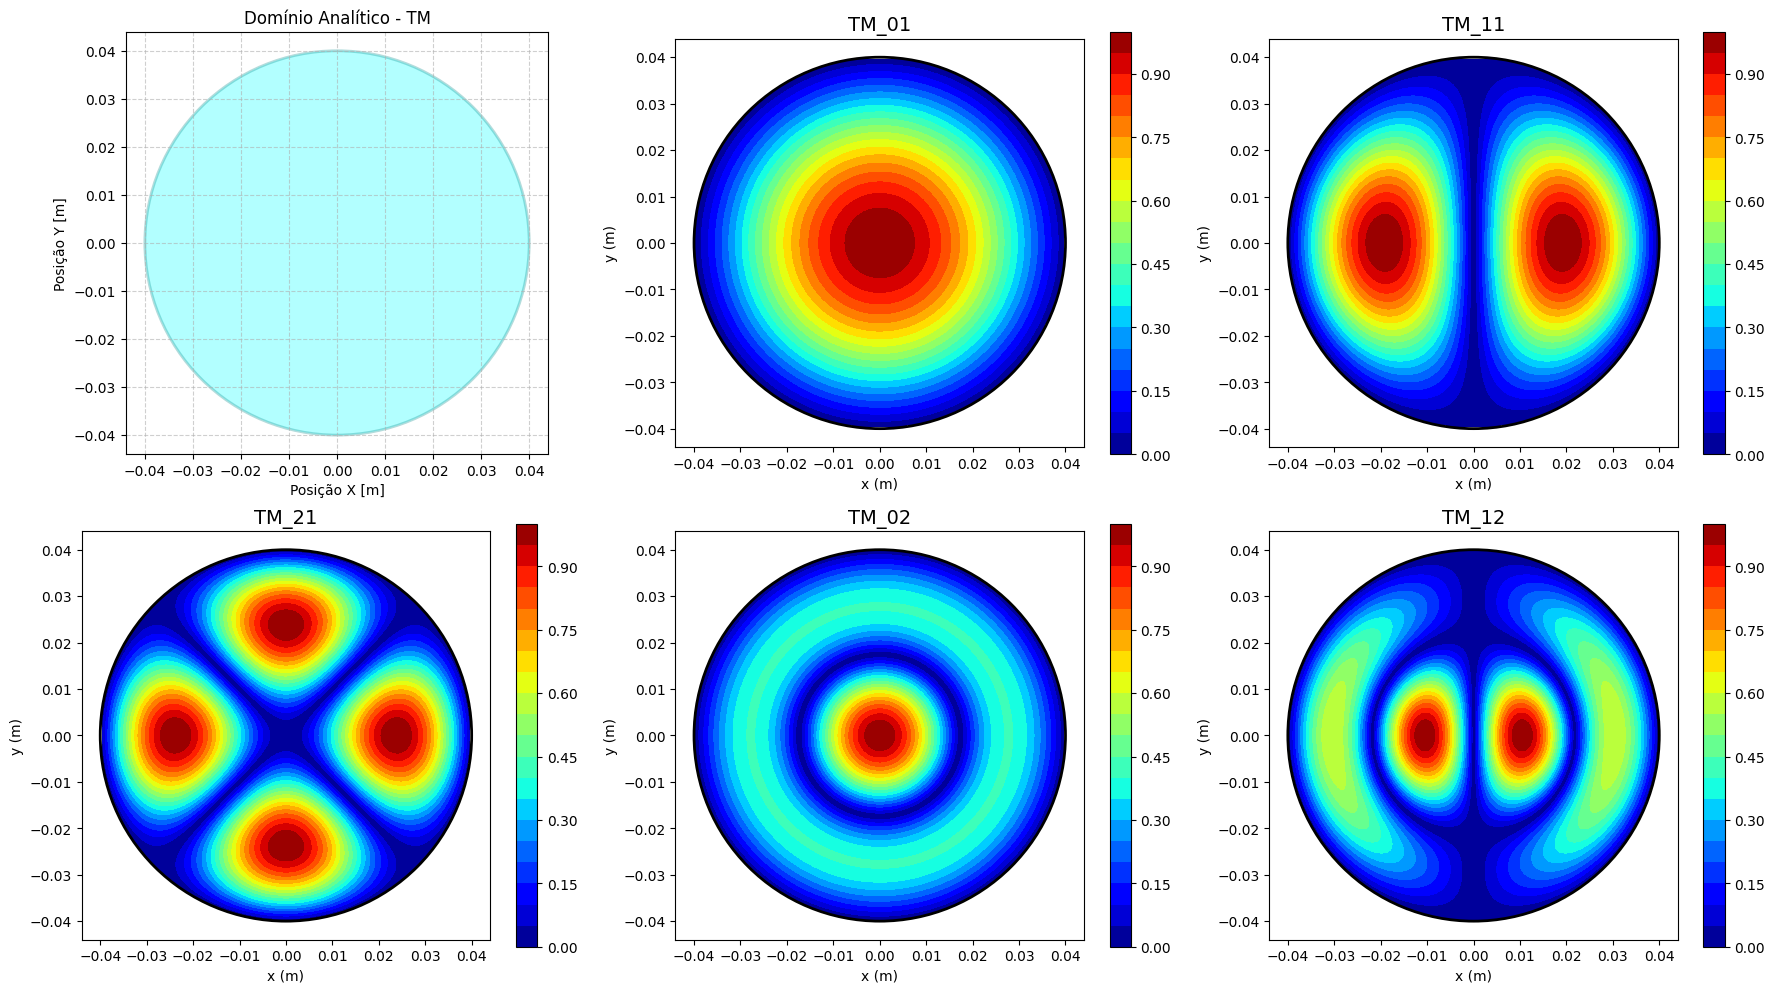

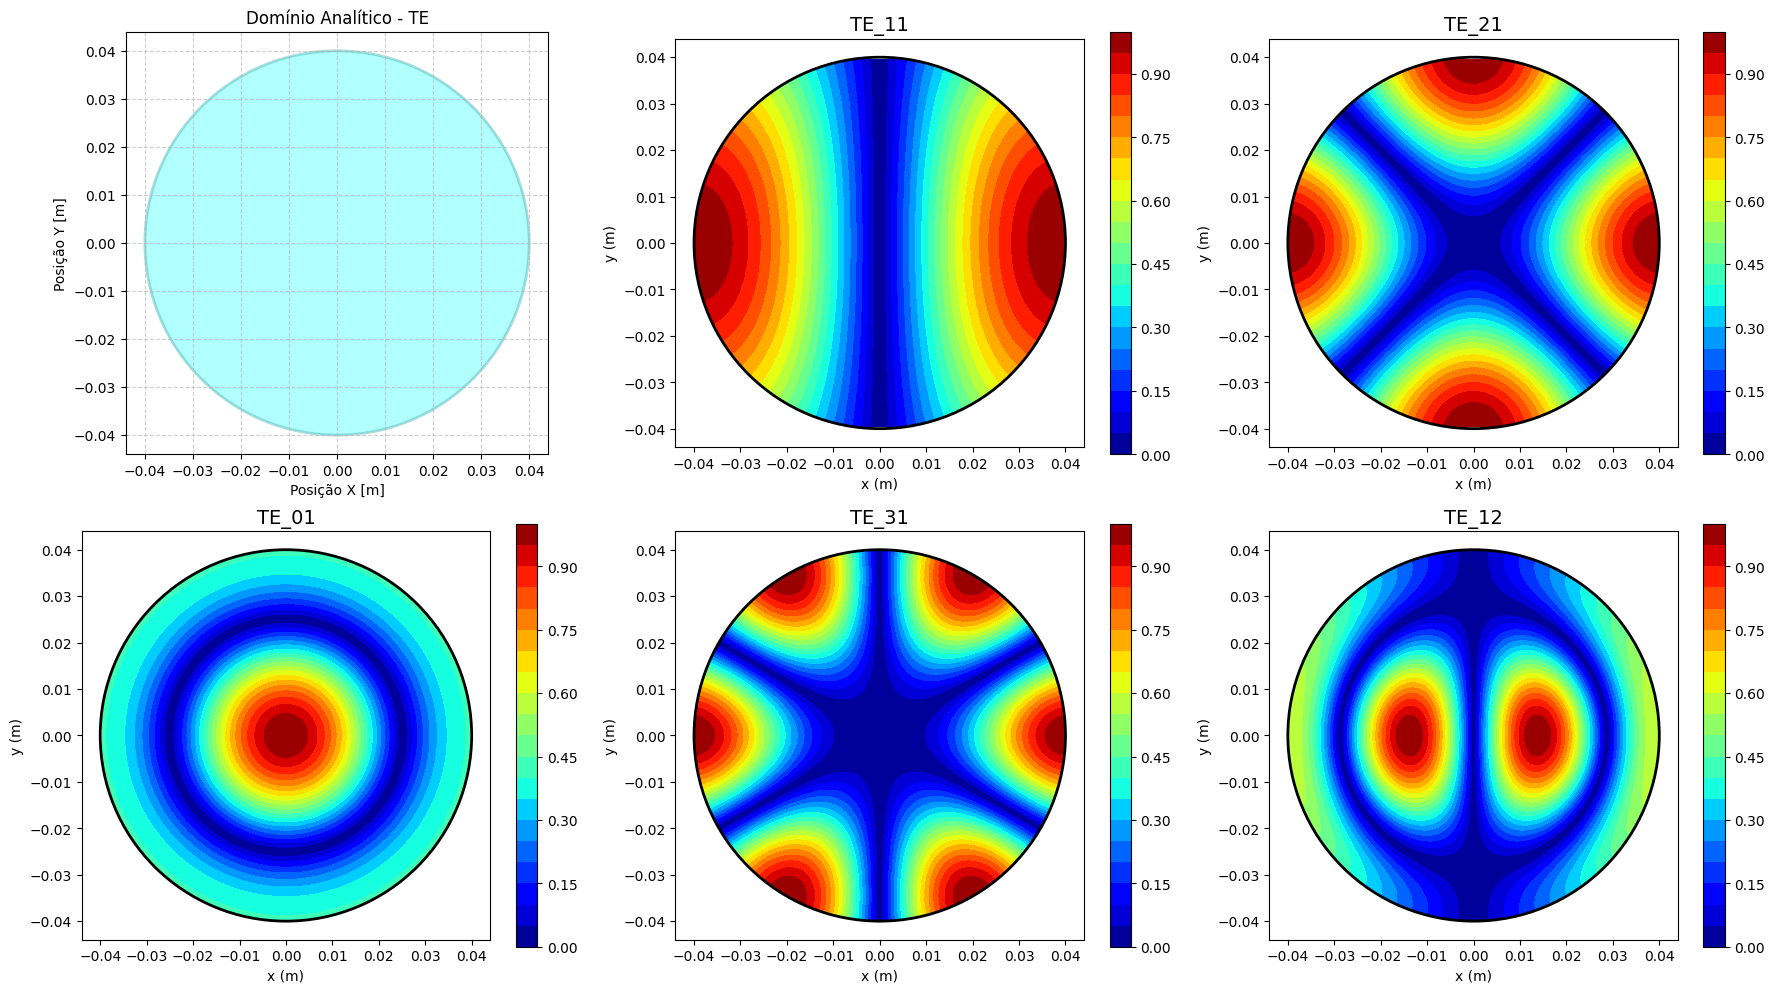

In [ ]:
# 1. Definições da Seção Circular
raio_cm = 4.0
er_val = 1.0

# Instanciando o objeto (convertendo para metros)
secao_circ = SecaoCircular2D(R=raio_cm * sc.centi, er=er_val)

# 2. Mostrando um modo específico no console
n_modo = 1  # índice azimutal
m_modo = 1  # índice radial
tipo = 'TE' # Mude para 'TE' ou 'TM'

fc = secao_circ.freq_corte(n_modo, m_modo, tipo)

print("==========================================")
print(f"Modo Selecionado: {tipo}_{n_modo}{m_modo}")
print(f"Frequência de Corte: {fc/1e9:.4f} GHz")
print("==========================================\n")

# 3. Renderizando os painéis idênticos aos anteriores (normalizados 0 a 1)
# O código ajusta os picos das funções de Bessel e oculta o exterior do círculo.
plotar_painel_modos_circular(secao_circ, tipo_modo='TM')
plotar_painel_modos_circular(secao_circ, tipo_modo='TE')  